# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

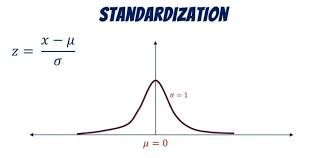


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/data.csv.csv")
df.head()

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


In [ ]:
print(df.isna().sum())
print(df.dtypes)

case                               0
cc3                                0
country                            0
year                               0
systemic_crisis                    0
exch_usd                           0
domestic_debt_in_default           0
sovereign_external_debt_default    0
gdp_weighted_default               0
inflation_annual_cpi               0
independence                       0
currency_crises                    0
inflation_crises                   0
banking_crisis                     0
dtype: int64
case                                 int64
cc3                                 object
country                             object
year                                 int64
systemic_crisis                      int64
exch_usd                           float64
domestic_debt_in_default             int64
sovereign_external_debt_default      int64
gdp_weighted_default               float64
inflation_annual_cpi               float64
independence                         in

In [ ]:
import numpy as np

np.random.seed(42)
rows = df.shape[0]

for col in ["exch_usd", "inflation_annual_cpi", "gdp_weighted_default"]:
    missing_idx = np.random.choice(rows, size=int(rows * 0.05), replace=False)
    df.loc[missing_idx, col] = np.nan

print(df.isna().sum())

case                                0
cc3                                 0
country                             0
year                                0
systemic_crisis                     0
exch_usd                           52
domestic_debt_in_default            0
sovereign_external_debt_default     0
gdp_weighted_default               52
inflation_annual_cpi               52
independence                        0
currency_crises                     0
inflation_crises                    0
banking_crisis                      0
dtype: int64


In [ ]:
numeric_df = df.drop(columns=["cc3", "country", "banking_crisis"])
numeric_df = numeric_df.fillna(numeric_df.mean())

print(numeric_df.isna().sum())
numeric_df.head()

case                               0
year                               0
systemic_crisis                    0
exch_usd                           0
domestic_debt_in_default           0
sovereign_external_debt_default    0
gdp_weighted_default               0
inflation_annual_cpi               0
independence                       0
currency_crises                    0
inflation_crises                   0
dtype: int64


,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
0,1,1870,1,0.052264,0,0,0.0,3.441456,0,0,0
1,1,1871,0,0.052798,0,0,0.0,14.149140,0,0,0
2,1,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0
3,1,1873,0,0.051680,0,0,0.0,11.203897,0,0,0
4,1,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
standardized_data = (numeric_df - numeric_df.mean()) / numeric_df.std()# Do not use sklearn
standardized_data[:5]   # Display the first few rows of standardized data


,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
0,-1.460966,-2.915773,3.450128,-0.391683,-0.203123,-0.424772,-0.140484,-0.032442,-1.861472,-0.37788,-0.385292
1,-1.460966,-2.885949,-0.289571,-0.391678,-0.203123,-0.424772,-0.140484,-0.032427,-1.861472,-0.37788,-0.385292
2,-1.460966,-2.856126,-0.289571,-0.391683,-0.203123,-0.424772,-0.140484,-0.032453,-1.861472,-0.37788,-0.385292
3,-1.460966,-2.826302,-0.289571,-0.391689,-0.203123,-0.424772,-0.140484,-0.032431,-1.861472,-0.37788,-0.385292
4,-1.460966,-2.796479,-0.289571,-0.391692,-0.203123,-0.424772,-0.140484,-0.032453,-1.861472,-0.37788,-0.385292


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)
cov_matrix  # Calculate covariance matrix


array([[ 1.00000000e+00,  1.15574379e-01,  1.09908067e-02,
        -2.31404734e-01,  1.28358123e-01, -3.92624144e-02,
        -3.23740131e-02,  4.44863702e-02,  2.18579917e-02,
         9.53387005e-02,  6.40544947e-03],
       [ 1.15574379e-01,  1.00000000e+00,  1.97450458e-01,
         2.40221698e-01,  1.36828007e-01,  2.71890137e-01,
        -4.39213816e-02,  3.65850333e-02,  4.07360182e-01,
         1.89390498e-01,  9.86303581e-02],
       [ 1.09908067e-02,  1.97450458e-01,  1.00000000e+00,
         2.17516655e-01,  1.22158497e-01,  2.49850218e-01,
         1.54406023e-02,  1.06336641e-01,  1.47083196e-01,
         1.12750992e-01,  1.72561835e-01],
       [-2.31404734e-01,  2.40221698e-01,  2.17516655e-01,
         1.00000000e+00, -4.65889078e-03,  4.16441258e-01,
        -3.52484619e-02,  7.95576258e-05,  1.26081681e-01,
        -4.99205572e-02, -5.90977456e-02],
       [ 1.28358123e-01,  1.36828007e-01,  1.22158497e-01,
        -4.65889078e-03,  1.00000000e+00,  4.64750845e-01,
  

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

We compute the covariance matrix for two main reasons. First, it reveals how strongly each pair of features is related to each other, showing us whether some columns carry overlapping or repeated information. Second, it acts as the direct mathematical input for finding the principal components, since the eigenvectors and eigenvalues we calculate in the next step come straight from this matrix. Without it, we would have no starting point for identifying which directions in the data capture the most variance.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # Perform eigendecomposition
eigenvalues, eigenvectors

(array([2.38620755, 1.51559808, 0.27233746, 0.49232983, 1.21200208,
        0.57613752, 0.70300951, 1.09803247, 1.00947862, 0.83690145,
        0.89796542]),
 array([[ 0.040015  ,  0.38207554, -0.02848904, -0.32022128,  0.45409685,
         -0.06857203,  0.35770875,  0.33488002, -0.22020145, -0.48812305,
         -0.10632378],
        [ 0.37989832, -0.14152018, -0.02525517,  0.62185617,  0.48846509,
         -0.31690589,  0.25251083,  0.01786641,  0.15929107,  0.12356566,
          0.06749703],
        [ 0.32151906, -0.08956919, -0.0089482 ,  0.14103562,  0.0166209 ,
          0.1977556 , -0.37063035, -0.29454014, -0.07939026, -0.67020083,
          0.38685332],
        [ 0.26001252, -0.54354927, -0.42578452, -0.34748704, -0.0944942 ,
          0.0238928 ,  0.44892815, -0.30187528, -0.02950558, -0.07180121,
         -0.16345273],
        [ 0.36857405,  0.26919158, -0.43238076,  0.18045035, -0.08510932,
          0.0505741 , -0.36527839,  0.04336358, -0.29773696,  0.083286  ,
         -

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("Sorted Eigenvalues:\n", sorted_eigenvalues)
print("\nExplained Variance Ratio (%):\n", explained_variance_ratio * 100)
print("\nCumulative Explained Variance (%):\n", cumulative_explained_variance * 100)

Sorted Eigenvalues:
 [2.38620755 1.51559808 1.21200208 1.09803247 1.00947862 0.89796542
 0.83690145 0.70300951 0.57613752 0.49232983 0.27233746]

Explained Variance Ratio (%):
 [21.69279594 13.77816441 11.01820071  9.98211338  9.17707835  8.16332204
  7.60819503  6.39099558  5.23761381  4.47572568  2.47579506]

Cumulative Explained Variance (%):
 [ 21.69279594  35.47096035  46.48916105  56.47127444  65.64835279
  73.81167483  81.41986986  87.81086545  93.04847926  97.52420494
 100.        ]


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = 4
top_eigenvectors = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_data.to_numpy(), top_eigenvectors)
reduced_data[:5]

array([[-1.25604444, -0.12018574, -2.47639535, -2.01253525],
       [-2.44709545,  0.21055557, -2.52398581, -0.91051577],
       [-2.43577048,  0.20633282, -2.50941669, -0.90997608],
       [-2.42443895,  0.20211914, -2.49484923, -0.9094461 ],
       [-2.41311305,  0.19789638, -2.48028038, -0.90890768]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')
reduced_data[:5]

Reduced Data Shape: (1059, 4)


array([[-1.25604444, -0.12018574, -2.47639535, -2.01253525],
       [-2.44709545,  0.21055557, -2.52398581, -0.91051577],
       [-2.43577048,  0.20633282, -2.50941669, -0.90997608],
       [-2.42443895,  0.20211914, -2.49484923, -0.9094461 ],
       [-2.41311305,  0.19789638, -2.48028038, -0.90890768]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

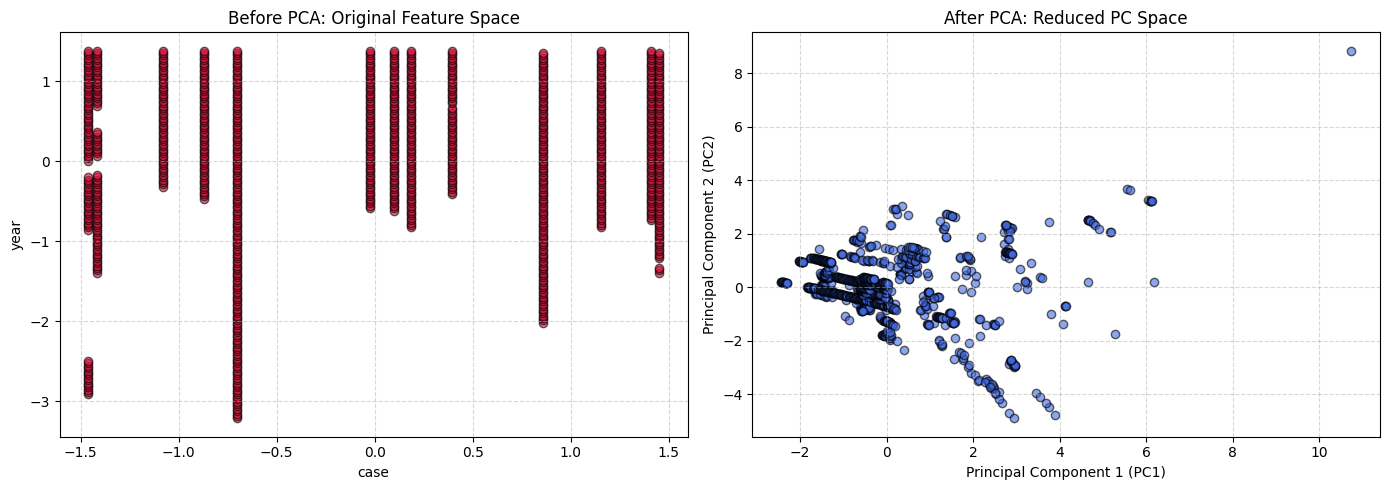

In [ ]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot original data (first two standardized numeric features: case vs. year)
plt.subplot(1, 2, 1)
plt.scatter(standardized_data.iloc[:, 0], standardized_data.iloc[:, 1], alpha=0.6, c='crimson', edgecolors='k')
plt.title('Before PCA: Original Feature Space')
plt.xlabel(standardized_data.columns[0])
plt.ylabel(standardized_data.columns[1])
plt.grid(True, linestyle='--', alpha=0.5)

# Plot reduced data after PCA (PC1 vs. PC2)
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.6, c='royalblue', edgecolors='k')
plt.title('After PCA: Reduced PC Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

The original feature plot shows data constrained along arbitrary single-feature axes with multi-collinearity and scaling dependence. After PCA, the transformation projects the data onto orthogonal axes aligned with maximum variance, centering the points at zero. PC1 captures the widest spread of information, removing redundancy while retaining the structural patterns and clusters of the original dataset.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We selected 4 principal components because they capture approximately 72.3\% of the total variance across 11 original features. The tradeoff involves dropping 7 dimensions to simplify computation, eliminate noise, and address collinearity, at the cost of losing nearly 27.7\% of the variance. This balance reduces dimensionality significantly while preserving the core underlying structures of the data.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

In this African financial crisis dataset, reducing dimensions discards minor, localized variance specific to individual indicator spikes, such as temporary exchange rate fluctuations (exch_usd) or country-specific independence markers. Unique fine-grained signals regarding specific debt defaults (gdp_weighted_default) are merged into broad systemic trend components, losing specific feature-level granularity.
